In [1]:
#Section 1 - Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import cv2
import random
import pickle
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.model_selection import train_test_split
from torchvision import models
from sklearn.metrics import accuracy_score

In [2]:
import sys
sys.path.append(os.path.abspath(".."))

In [3]:
#Section 2 - Device Configuration

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using device: cpu
Using Apple GPU (MPS)


In [4]:
from src.data_loader import *
from src.transforms import *
from src.models import *
from src.train import *
from src.evaluate import *
print("Data Loader Imported Successfully")

Train Shape: (9580, 48, 48, 3)
Validation Shape: (2395, 48, 48, 3)
Test Shape: (6065, 48, 48, 3)
Unique Labels: [0 1 2]
Converted Train Labels: [0 1]
Converted Validation Labels: [0 1]
Converted Test Labels: [0 1]
Train Label Distribution:
[3200 6380]
Validation Label Distribution:
[ 875 1520]
Test Label Distribution:
[2245 3820]
Tomato Images: 20955
Maize Images: 400
Tomato Labels: [0 1]
Maize Labels: [0 1]
Tomato Train: 14668
Tomato Validation: 3143
Tomato Test: 3144
Maize Train: 280
Maize Validation: 60
Maize Test: 60
Using Apple GPU (MPS)
All Baseline Models Created Successfully
All Improved Models Created Successfully
Feature Extractors Created
Fusion Model Created Successfully
Domain Generalisation Model Created Successfully
Data Loader Imported Successfully


In [5]:
#Section 3 - Build Multiclass Datasets

# Training datasets — with augmentation
dg_tomato_train = DomainLeafDataset(
    train_tomato_data, train_tomato_labels,
    domain_id=0, transform=dg_transform
)
 
dg_maize_train = DomainLeafDataset(
    train_maize_data, train_maize_labels,
    domain_id=1, transform=dg_transform
)
 
dg_maize2_train = DomainLeafDataset(
    list(train_maize2_data), list(train_maize2_labels),
    domain_id=2, transform=dg_transform
)
 
# Validation datasets — no augmentation
dg_tomato_val = DomainLeafDataset(
    val_tomato_data, val_tomato_labels,
    domain_id=0, transform=dg_val_transform
)
 
dg_maize_val = DomainLeafDataset(
    val_maize_data, val_maize_labels,
    domain_id=1, transform=dg_val_transform
)
 
dg_maize2_val = DomainLeafDataset(
    list(val_maize2_data), list(val_maize2_labels),
    domain_id=2, transform=dg_val_transform
)
 
# Test datasets — no augmentation
dg_tomato_test = DomainLeafDataset(
    test_tomato_data, test_tomato_labels,
    domain_id=0, transform=dg_val_transform
)
 
dg_maize_test = DomainLeafDataset(
    test_maize_data, test_maize_labels,
    domain_id=1, transform=dg_val_transform
)
 
dg_maize2_test = DomainLeafDataset(
    list(test_maize2_data), list(test_maize2_labels),
    domain_id=2, transform=dg_val_transform
)
 
# ConcatDataset merges all 3 into one unified pool then the model sees tomato, maize, maize2 samples side-by-side in the same update
dg_train_combined = ConcatDataset([dg_tomato_train, dg_maize_train, dg_maize2_train])
dg_val_combined   = ConcatDataset([dg_tomato_val,   dg_maize_val,   dg_maize2_val])
dg_test_combined  = ConcatDataset([dg_tomato_test,  dg_maize_test,  dg_maize2_test])
 
print(f"Train samples: {len(dg_train_combined)}")
print(f"Val samples:   {len(dg_val_combined)}")
print(f"Test samples:  {len(dg_test_combined)}")

Train samples: 24528
Val samples:   5598
Test samples:  9269


In [6]:
#Section 4 - DataLoaders for Domain Generalization

dg_batch_size = 32
 
dg_train_loader = DataLoader(
    dg_train_combined,
    batch_size=dg_batch_size,
    shuffle=True,           # Shuffle mixes all 3 domains within each batch
    num_workers=0,          
    pin_memory=True         # Faster GPU transfer
)
 
dg_val_loader = DataLoader(
    dg_val_combined,
    batch_size=dg_batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
 
dg_test_loader = DataLoader(
    dg_test_combined,
    batch_size=dg_batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [7]:
#Section 7 - Initiate model, loss and optimizer

dg_model = DomainGeneralisationModel(num_domains=3).to(device)
 
# Stress loss - standard CrossEntropyLoss
# Why CE - binary classification with softmax
dg_stress_criterion = nn.CrossEntropyLoss()
 
# Domain loss: also CrossEntropyLoss over 3 classes (the 3 domains)
dg_domain_criterion = nn.CrossEntropyLoss()
 
# ONE optimiser for the WHOLE model — no need for 3 separate optimisers like ensemble.
dg_optimizer = torch.optim.Adam(
    dg_model.parameters(),
    lr=0.0001,
    weight_decay=1e-4       # L2 regularisation — helps generalisation across domains
)
 
# Learning rate scheduler - reduces lr when validation accuracy plateaus.
# Why - domain generalisation training can stall; scheduler rescues it automatically.
dg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    dg_optimizer,
    mode='max',             # Maximise val accuracy
    patience=3,             # Wait 3 epochs of no improvement before reducing lr
    factor=0.5             # Halve the lr
)
 
print("Domain Generalisation Model created successfully.")
print(f"Total parameters: {sum(p.numel() for p in dg_model.parameters()):,}")

Domain Generalisation Model created successfully.
Total parameters: 3,274,373


In [ ]:
#Section 9 - Run Training

print("Training Domain Generalisation Model")
print("=" * 75)
 
dg_stress_losses, dg_domain_losses, dg_train_accs, dg_val_accs = train_domain_generalisation(
    model=dg_model,
    train_loader=dg_train_loader,
    val_loader=dg_val_loader,
    optimizer=dg_optimizer,
    scheduler=dg_scheduler,
    dg_stress_criterion=dg_stress_criterion,
    dg_domain_criterion=dg_domain_criterion,
    device=device,
    epochs=25                    # More epochs than your 15 — DG needs more time
                                        # to converge because it's optimising two objectives
)

Training Domain Generalisation Model


/Users/manish/Library/r-miniconda-arm64/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch [01/25] | λ=0.000 | Stress Loss: 0.1262 | Domain Loss: 1.1045 | Val Accuracy: 96.86%
---------------------------------------------------------------------------
Epoch [02/25] | λ=0.197 | Stress Loss: 0.0609 | Domain Loss: 0.0454 | Val Accuracy: 98.09%
---------------------------------------------------------------------------
Epoch [03/25] | λ=0.380 | Stress Loss: 0.0660 | Domain Loss: 0.4019 | Val Accuracy: 96.66%
---------------------------------------------------------------------------
Epoch [04/25] | λ=0.537 | Stress Loss: 0.0899 | Domain Loss: 0.7476 | Val Accuracy: 97.84%
---------------------------------------------------------------------------
Epoch [05/25] | λ=0.664 | Stress Loss: 0.1014 | Domain Loss: 0.9200 | Val Accuracy: 95.91%
---------------------------------------------------------------------------
Epoch [06/25] | λ=0.762 | Stress Loss: 0.0779 | Domain Loss: 0.7589 | Val Accuracy: 97.07%
--------------------------------------------------------------------------

In [9]:
# ============================================================
# SECTION 9.5 - SAVE DG TRAINING HISTORY
# ============================================================

# Create folder if not exists
os.makedirs("saved_models", exist_ok=True)

# Store training curves/history
training_history = {

    "stress_losses": dg_stress_losses,

    "domain_losses": dg_domain_losses,

    "val_accuracies": dg_val_accs
}

# Save history
with open(
    "saved_models/dg_training_history.pkl",
    "wb"
) as f:

    pickle.dump(training_history, f)

print("DG training history saved successfully")

DG training history saved successfully


In [14]:
# ============================================================
# SECTION 10 - SAVE DOMAIN GENERALISATION MODEL
# ============================================================

import os

# Create folder if not exists
os.makedirs("saved_models", exist_ok=True)

# Save DG model
torch.save(
    dg_model.state_dict(),
    "saved_models/dg_model.pth"
)

print("Domain Generalisation Model Saved Successfully")

Domain Generalisation Model Saved Successfully


In [15]:
# ============================================================
# SECTION 9 - LOAD DOMAIN GENERALISATION MODEL
# ============================================================

dg_model.load_state_dict(
    torch.load(
        "saved_models/dg_model.pth",
        map_location=device
    )
)

# Set evaluation mode
dg_model.eval()

print("Domain Generalisation Model Loaded Successfully")

Domain Generalisation Model Loaded Successfully


In [16]:
#Section 11 - Run Evaluation

dg_accuracy, dg_preds, dg_labels, dg_domains = evaluate_dg_model(

    dg_model,
    dg_test_loader,
    device,
    dataset_name="Domain Generalisation"
)

  Domain Generalisation Test Accuracy: 97.05%

Per-Domain Accuracy:
  Tomato              : 100.00%  (3144/3144)
  Maize (folder)      : 90.00%  (54/60)
  Maize2 (.npy)       : 95.60%  (5798/6065)


/var/folders/s7/3fvv5dm16bncgf7d7m_411pc0000gn/T/ipykernel_47833/777977248.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-o" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(epochs, domain_losses, 'r-o', markersize=4, color='orange')


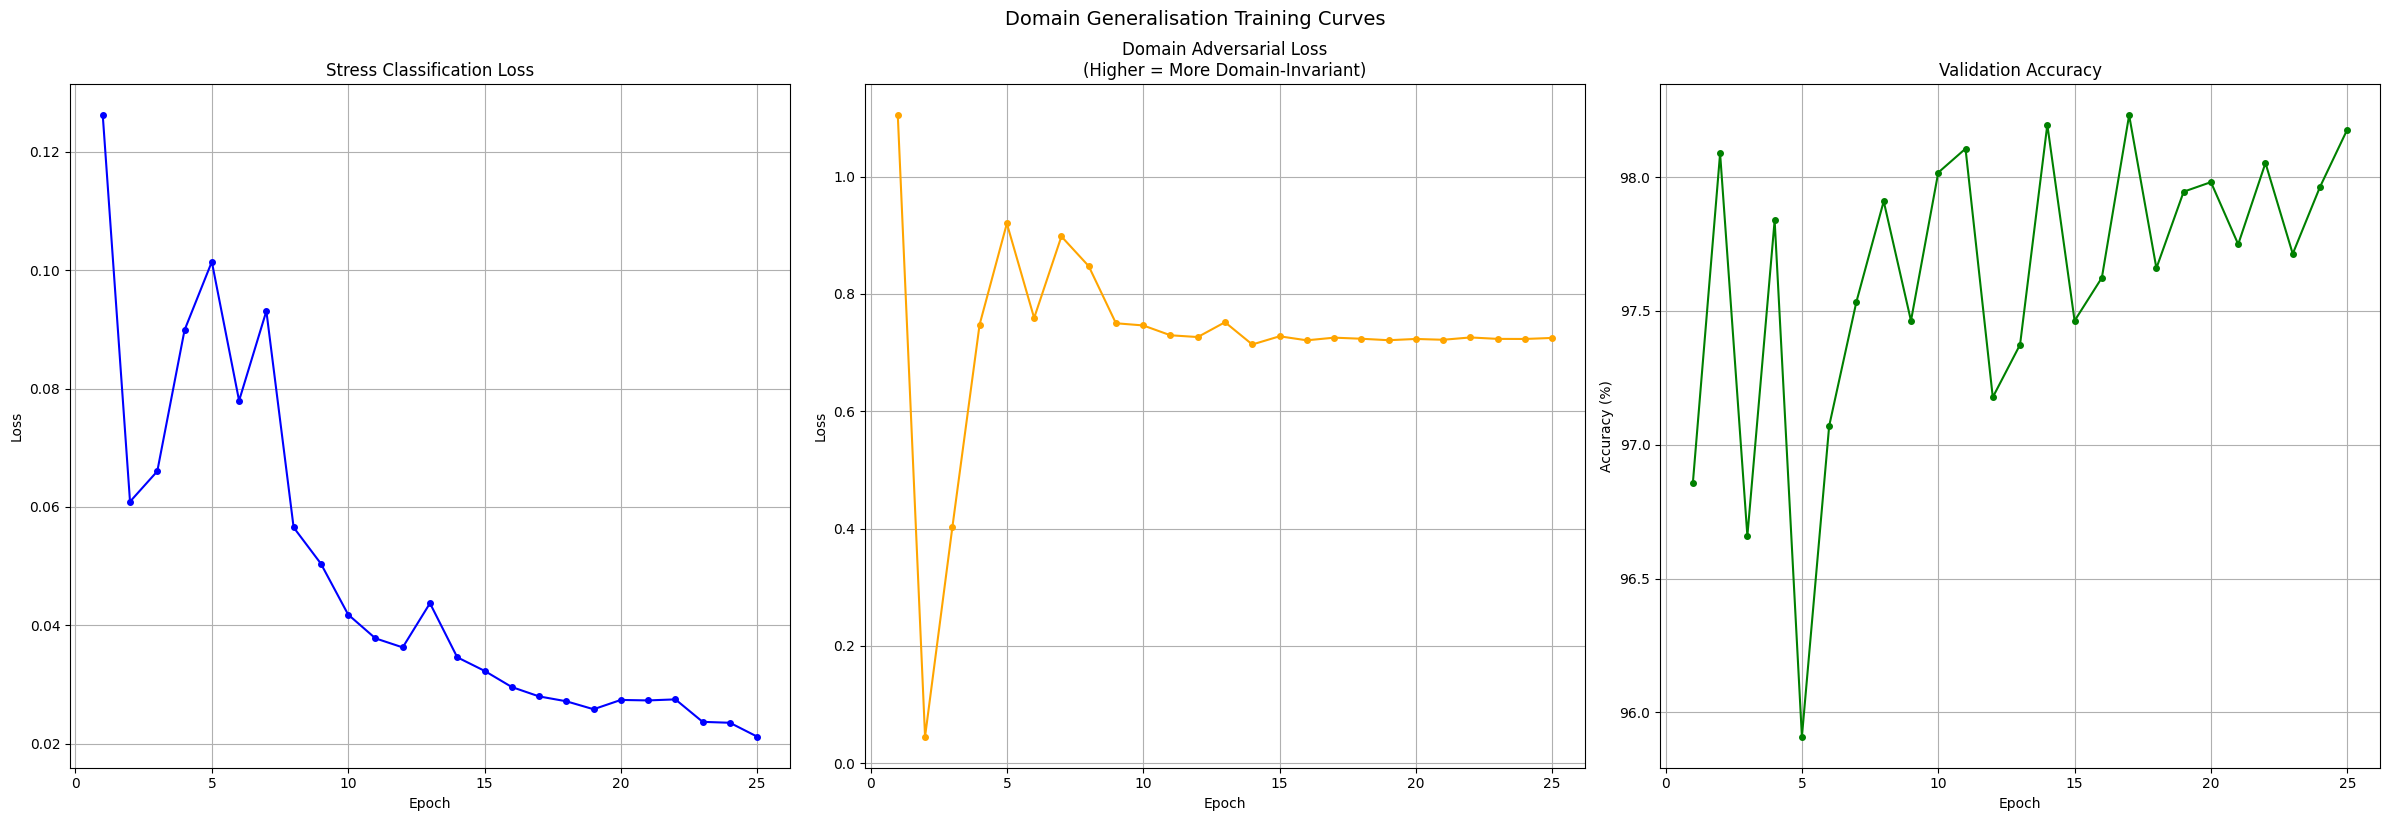

In [17]:
# SECTION 12 — Training Curves
# =============================================================================
 
def plot_training_curves(stress_losses, domain_losses, val_accs):
    """
    Plots the training history so you can diagnose:
    - Is stress loss decreasing? (model is learning)
    - Is domain loss stable/high? (model is successfully domain-blind)
    - Is val accuracy rising and plateauing? (generalising, not overfitting)
    """
    epochs = range(1, len(stress_losses) + 1)
 
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
 
    # Plot 1: Stress Loss
    axes[0].plot(epochs, stress_losses, 'b-o', markersize=4)
    axes[0].set_title("Stress Classification Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True)
 
    # Plot 2: Domain Loss
    # A healthy domain loss stays relatively HIGH (model can't identify domains)
    # If it drops to near 0, the backbone is still domain-specific → try increasing lambda
    axes[1].plot(epochs, domain_losses, 'r-o', markersize=4, color='orange')
    axes[1].set_title("Domain Adversarial Loss\n(Higher = More Domain-Invariant)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True)
 
    # Plot 3: Validation Accuracy
    axes[2].plot(epochs, val_accs, 'g-o', markersize=4)
    axes[2].set_title("Validation Accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Accuracy (%)")
    axes[2].grid(True)
 
    plt.tight_layout()
    plt.suptitle("Domain Generalisation Training Curves", y=1.02, fontsize=14)
    plt.show()
 
 
plot_training_curves(dg_stress_losses, dg_domain_losses, dg_val_accs)